In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("clean_aqi_dataset.csv")

In [2]:
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1210 entries, 0 to 1209
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   state/union_territory  1210 non-null   object 
 1   city/town/village      1210 non-null   object 
 2   year                   1210 non-null   int64  
 3   so2                    1210 non-null   float64
 4   no2                    1210 non-null   float64
 5   pm10                   1210 non-null   float64
 6   pm2.5                  1210 non-null   float64
dtypes: float64(4), int64(1), object(2)
memory usage: 66.3+ KB


,state/union_territory,city/town/village,year,so2,no2,pm10,pm2.5
0,Andhra Pradesh,Amaravati,2021,14.0,12.0,55.0,28.0
1,Andhra Pradesh,Anatapur,2021,7.0,16.0,64.0,30.0
2,Andhra Pradesh,Chittor,2021,5.0,14.0,46.0,25.0
3,Andhra Pradesh,Eluru,2021,5.0,17.0,63.0,30.0
4,Andhra Pradesh,Guntur,2021,5.0,17.0,60.0,29.0


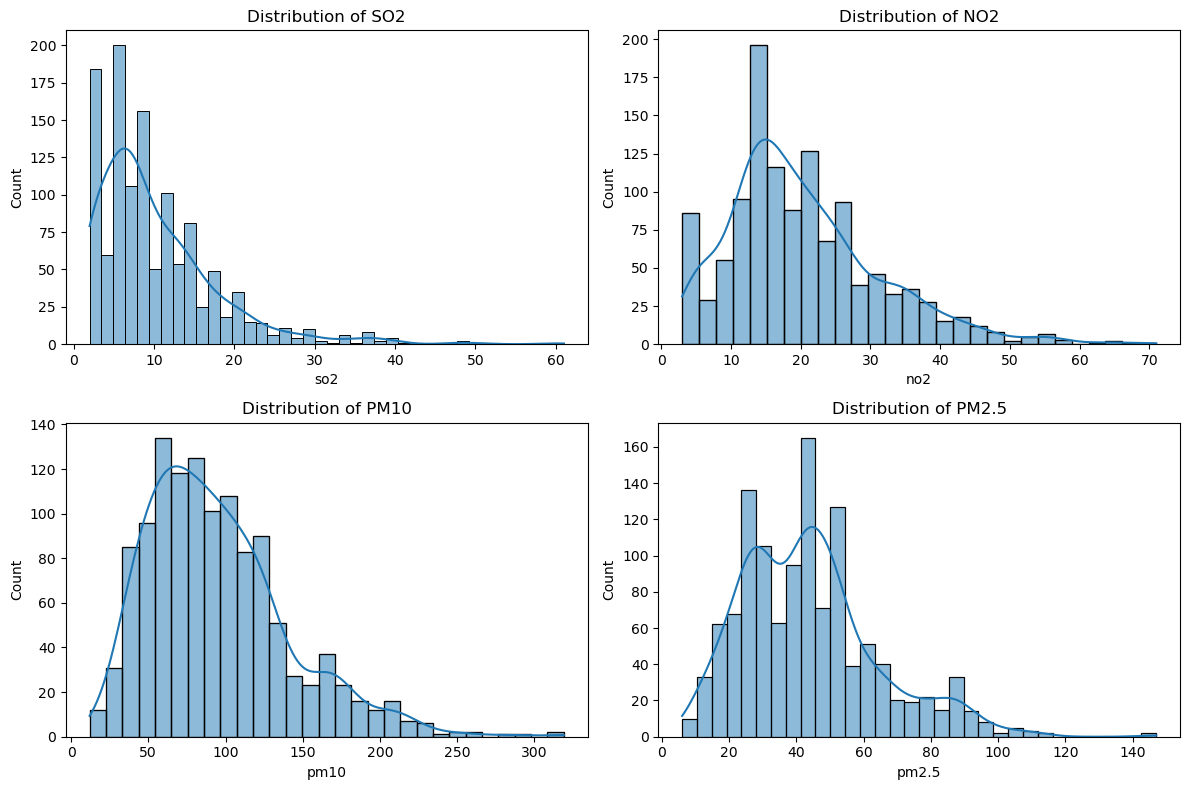

In [51]:
pollutants = ["so2","no2","pm10","pm2.5"]

plt.figure(figsize=(12, 8))
for i, col in enumerate(pollutants, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col.upper()}")
plt.tight_layout()
plt.show()

            so2        no2       pm10      pm2.5
year                                            
2021   9.646753  20.290909  93.618182  43.138961
2022  10.711944  21.370023  95.466042  44.045667
2023  10.321608  19.424623  95.057789  43.981156


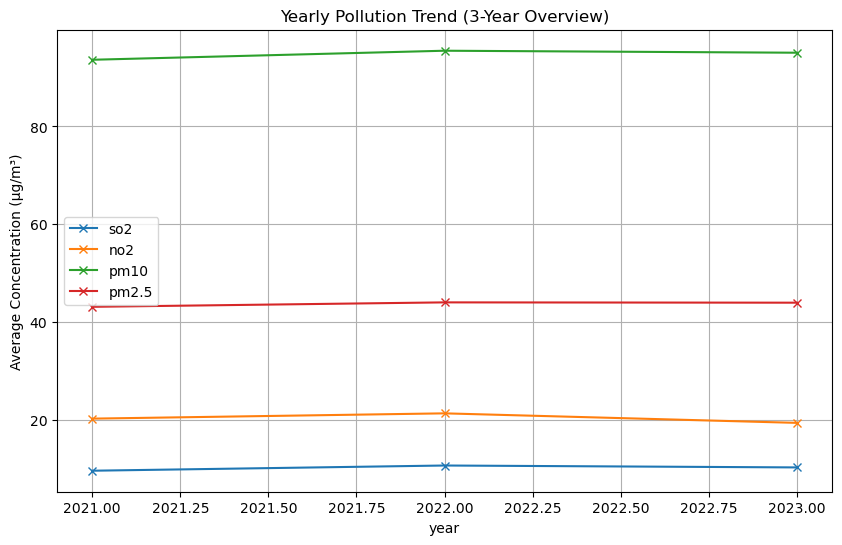

In [52]:
yearly_trend = df.groupby("year")[pollutants].mean()
print(yearly_trend)

yearly_trend.plot(figsize=(10,6), marker='x')
plt.title("Yearly Pollution Trend (3-Year Overview)")
plt.ylabel("Average Concentration (µg/m³)")
plt.grid(True)
plt.show()

                                                      so2        no2  \
state/union_territory                                                  
Andhra Pradesh                                   7.318182  18.250000   
Arunachal Pradesh                               15.000000   8.500000   
Assam                                            7.857143  12.828571   
Bihar                                            9.596154  31.038462   
Chandigarh (UT)                                  6.333333  25.333333   
Chattisgarh                                      9.823529  18.411765   
Dadara and Nagar Haveli and Daman and Diu (UT)  16.800000  21.800000   
Delhi (UT)                                       9.000000  40.333333   
Goa                                              5.941176  13.352941   
Gujara                                          13.000000  17.000000   

                                                      pm10       pm2.5  
state/union_territory                                         

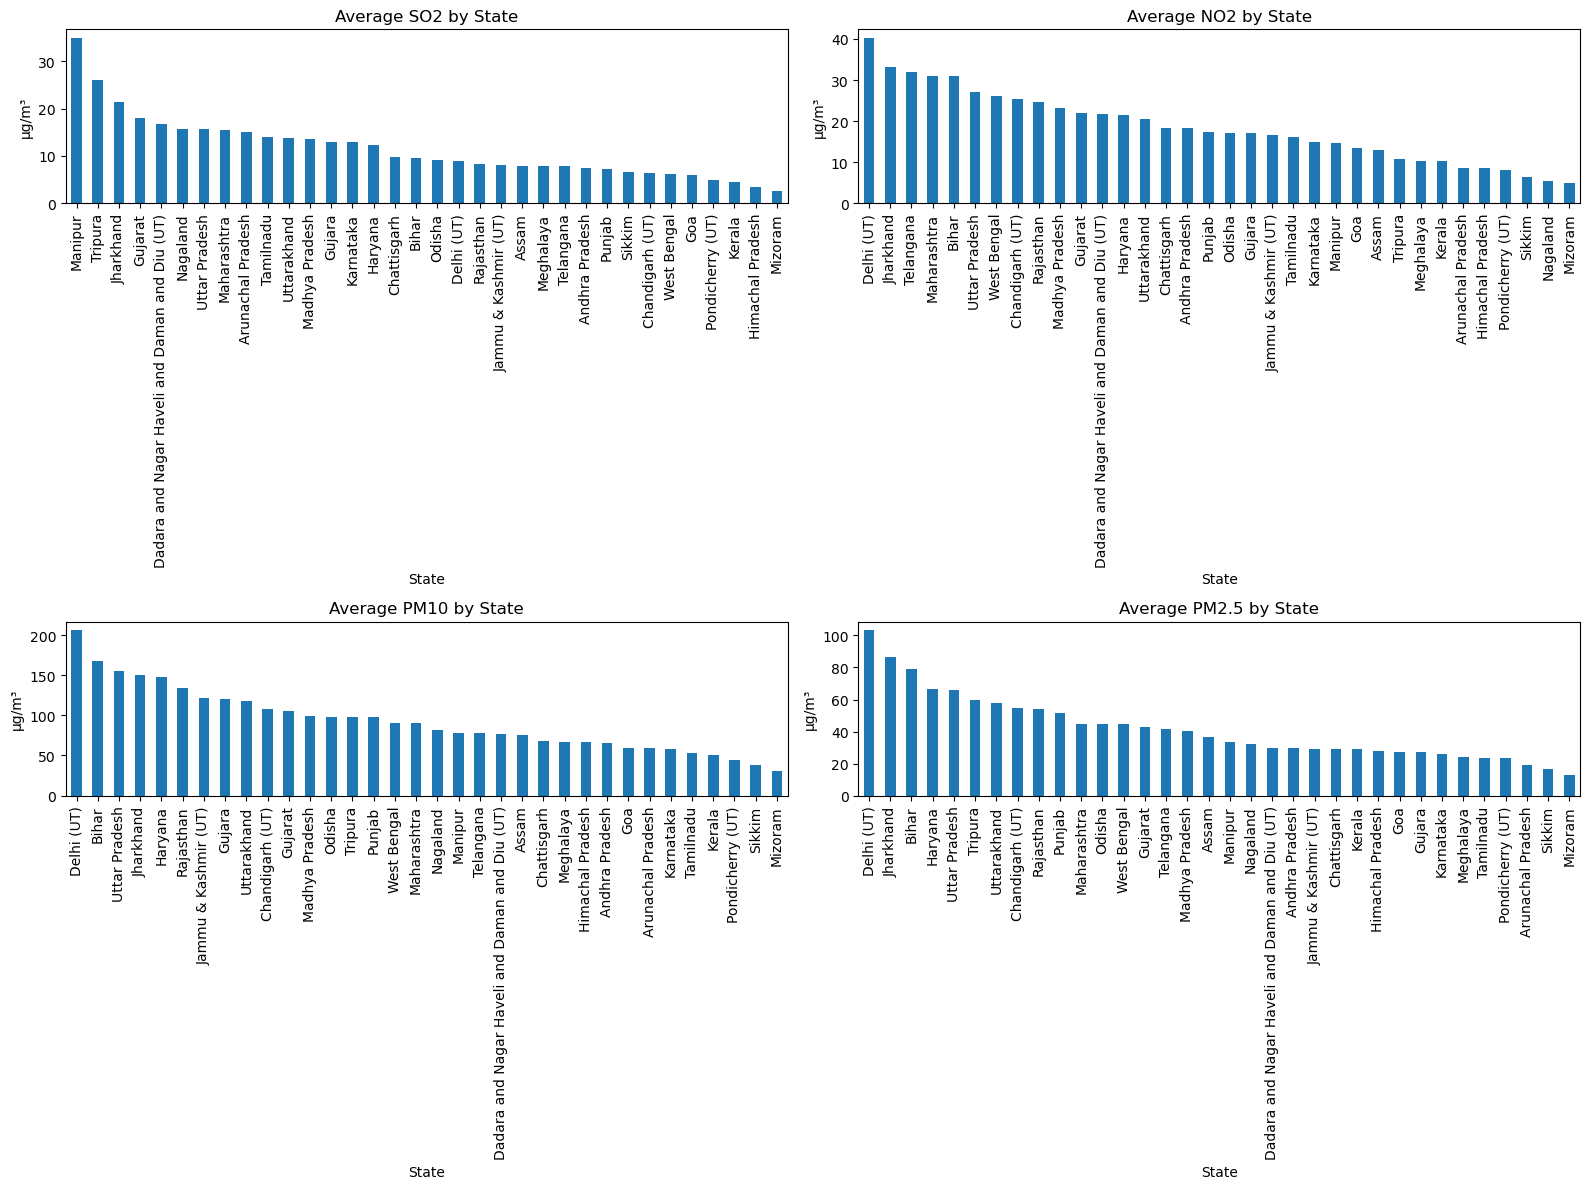

In [53]:
state_wise = df.groupby("state/union_territory")[pollutants].mean().sort_values("state/union_territory",ascending=True)
print(state_wise.head(10))
plt.figure(figsize=(16, 12))

for i, col in enumerate(pollutants, 1):
    plt.subplot(2, 2, i)
    state_wise[col].sort_values(ascending=False).plot(kind='bar')
    plt.title(f"Average {col.upper()} by State")
    plt.ylabel("µg/m³")
    plt.xlabel("State")
    plt.tight_layout()

plt.show()

                    so2        no2        pm10      pm2.5
city/town/village                                        
Adilabad            7.5  25.500000   64.500000  39.000000
Agartala           26.0  10.666667   97.666667  59.666667
Agra                9.5  20.500000  146.500000  75.500000
Ahmedabad          17.0  28.333333  111.666667  42.000000
Ahmednagar         11.0  31.000000   96.000000  34.000000
Aizwal              7.0   3.666667   45.000000  15.333333
Ajmer              15.0  24.333333  103.333333  47.333333
Akola              13.0  14.333333   67.333333  45.333333
Alappuzha           2.0   5.000000   48.666667  29.000000
Aligarh            17.5  27.000000  165.000000  66.000000


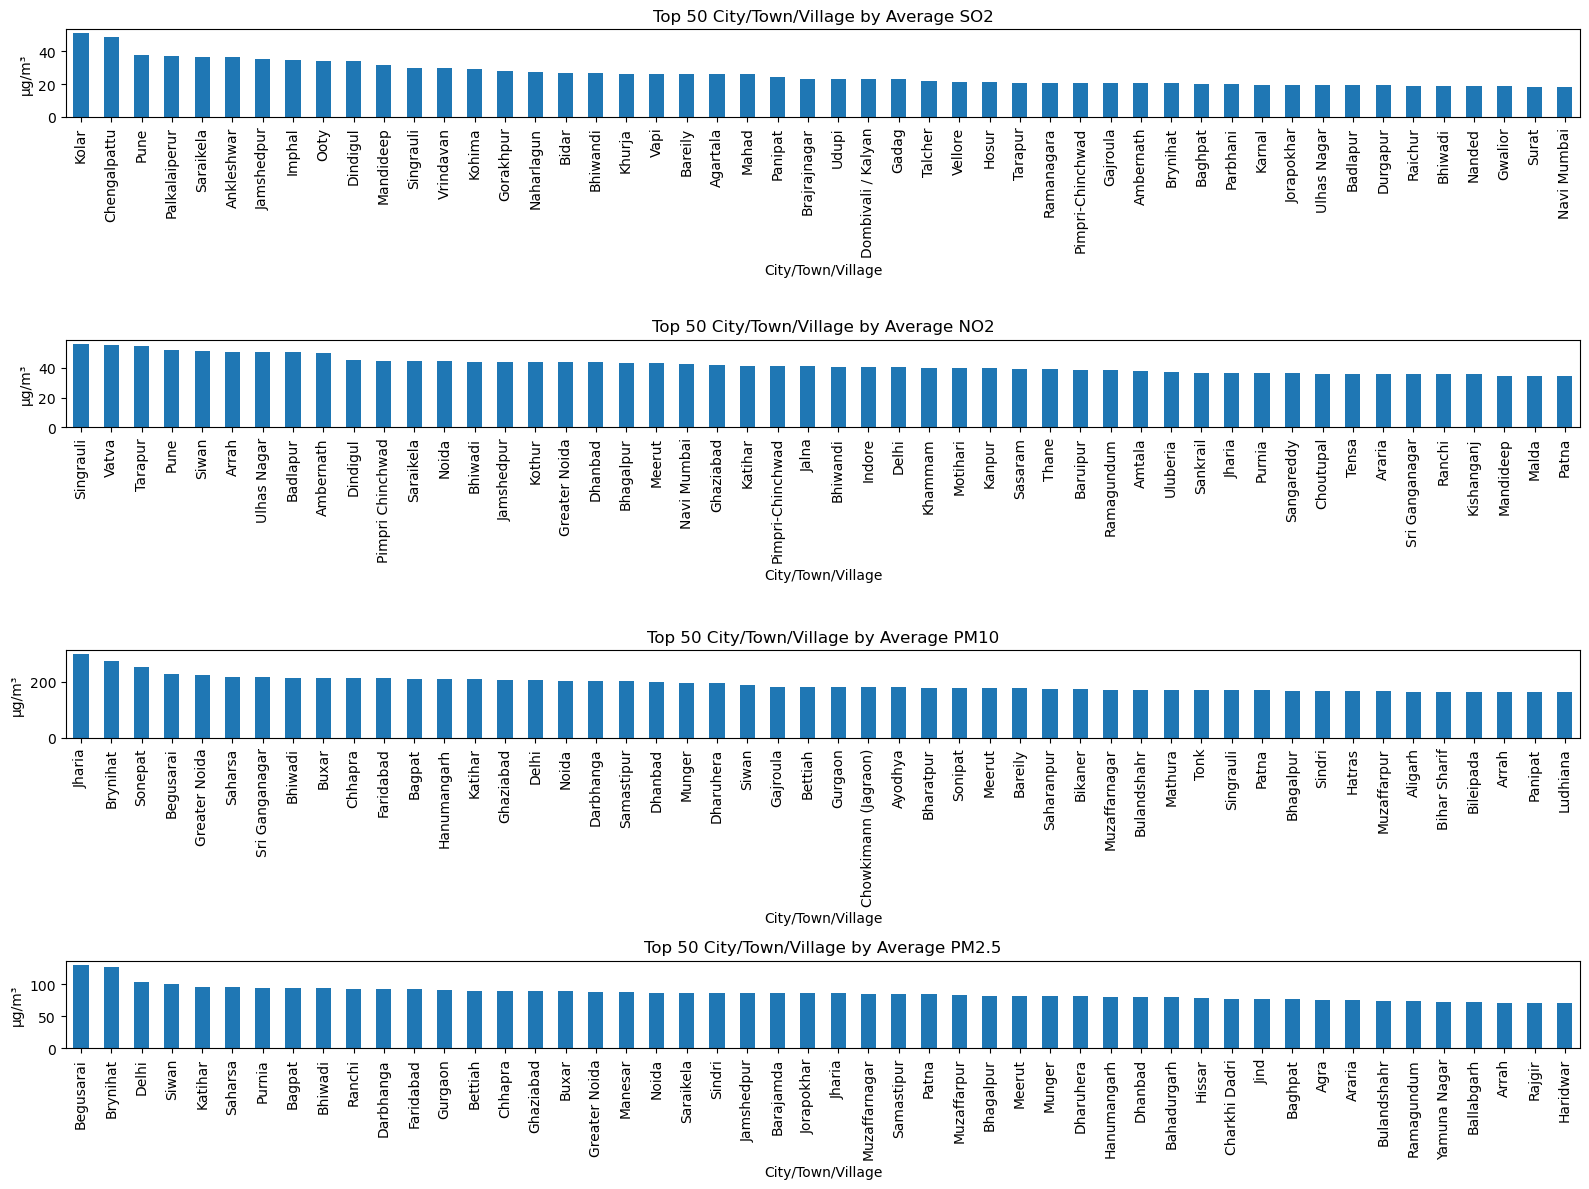

In [54]:
city_wise = df.groupby("city/town/village")[pollutants].mean().sort_values("city/town/village",ascending=True)
print(city_wise.head(10))
plt.figure(figsize=(16, 12))

for i, col in enumerate(pollutants, 1):
    plt.subplot(4, 1, i)
    city_wise[col].sort_values(ascending=False).head(50).plot(kind='bar')
    plt.title(f"Top 50 City/Town/Village by Average {col.upper()}")
    plt.ylabel("µg/m³")
    plt.xlabel("City/Town/Village")
    plt.tight_layout()

plt.show()

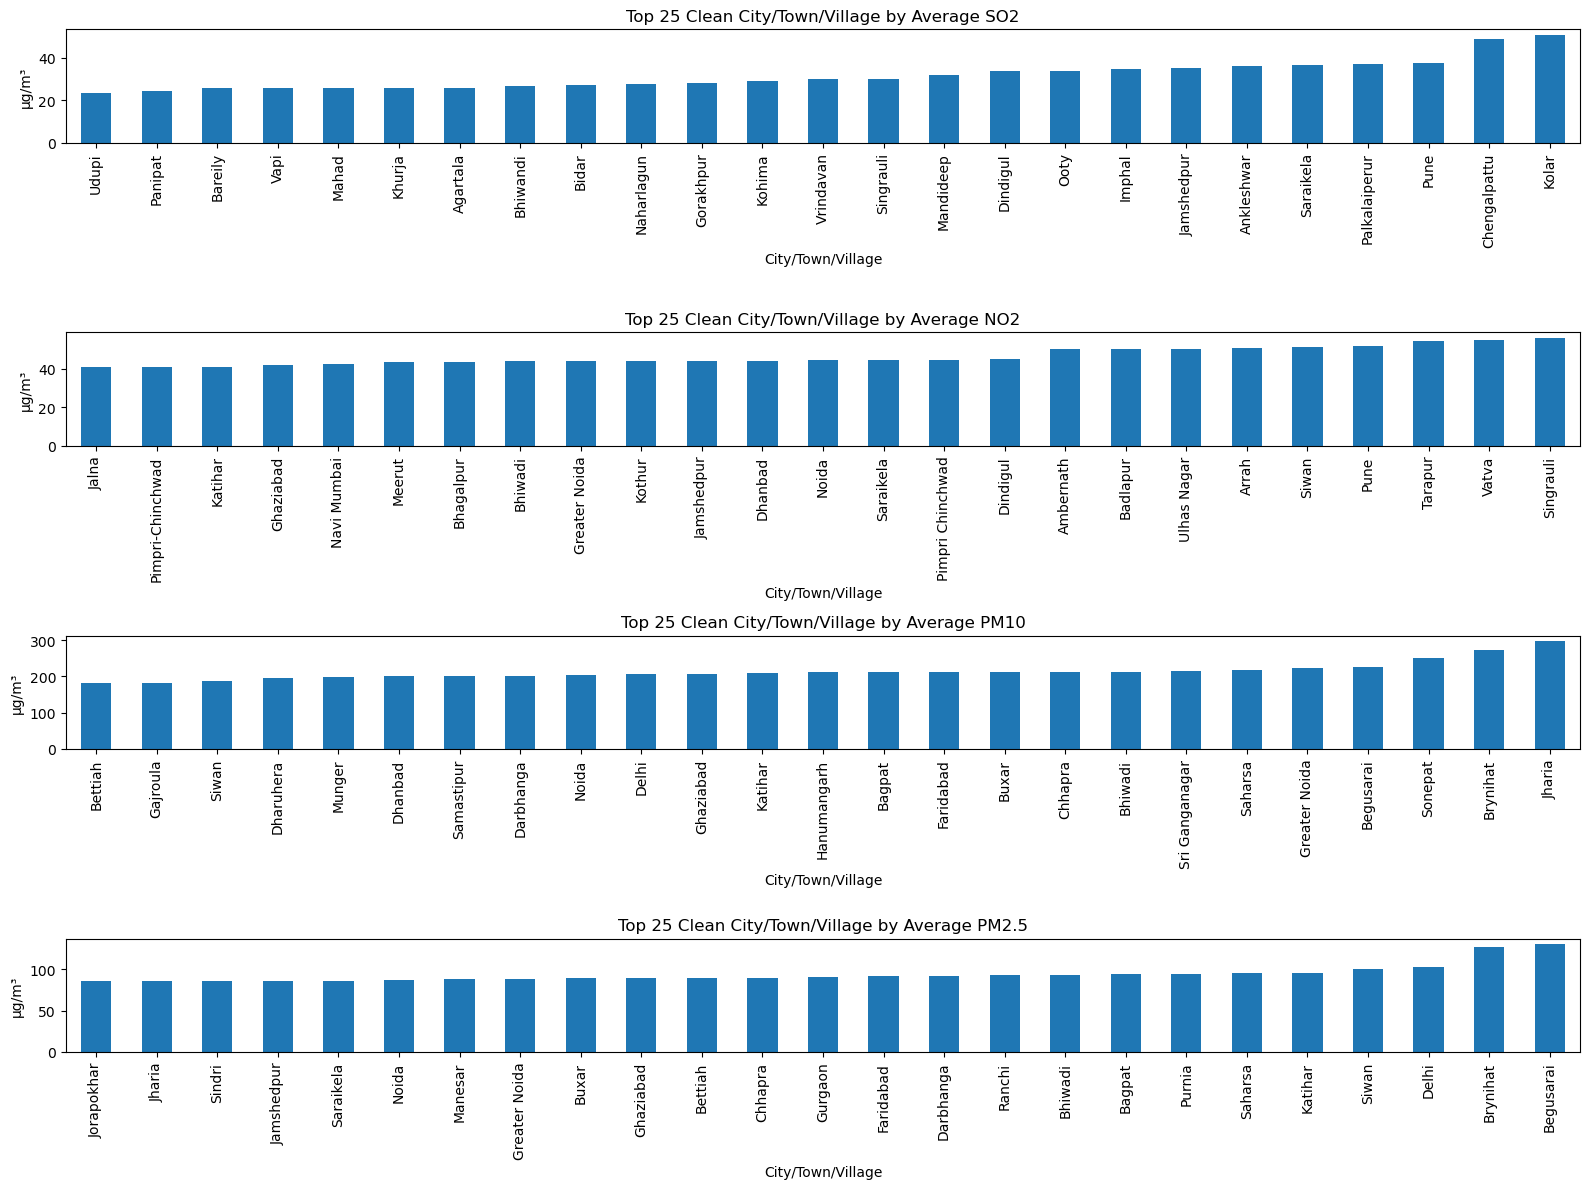

In [55]:
plt.figure(figsize=(16, 12))
for i, col in enumerate(pollutants, 1):
    plt.subplot(4, 1, i)
    city_wise[col].sort_values(ascending=True).tail(25).plot(kind='bar')
    plt.title(f"Top 25 Clean City/Town/Village by Average {col.upper()}")
    plt.ylabel("µg/m³")
    plt.xlabel("City/Town/Village")
    plt.tight_layout()

plt.show()

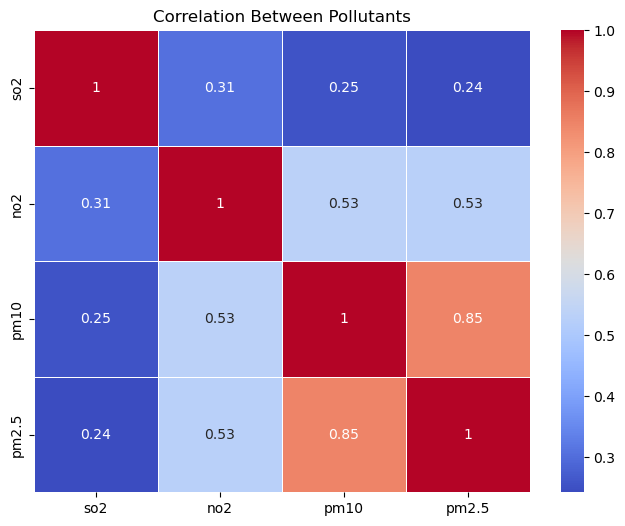

In [56]:
top_cities_pm25 = df.sort_values("pm2.5", ascending=False).head(10)
top_cities_pm25[["city/town/village", "state/union_territory", "pm2.5"]]

plt.figure(figsize=(8,6))
sns.heatmap(df[pollutants].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Between Pollutants")
plt.show()


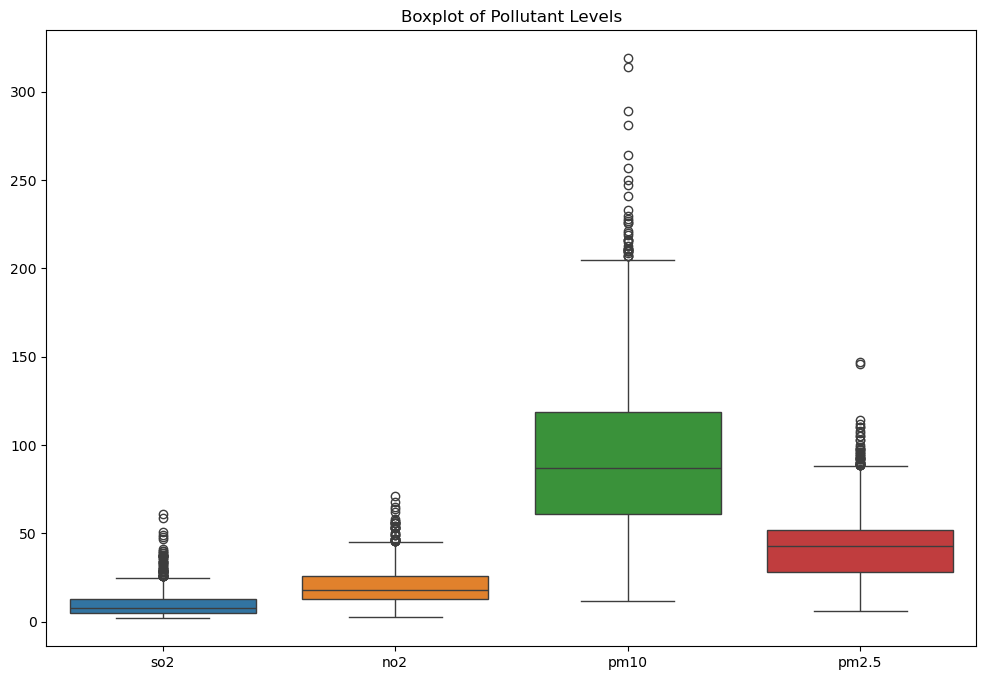

In [22]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df[pollutants])
plt.title("Boxplot of Pollutant Levels")
plt.show()